<a href="https://colab.research.google.com/github/gabguagon/Py-EDA-penguins/blob/main/penguins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA dataset pingüinos 🗺🧭🐧

In [2]:
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.6 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [5]:
!pip install palmerpenguins==0.1.4

  Using cached palmerpenguins-0.1.4-py3-none-any.whl.metadata (2.0 kB)


In [6]:
!pip install empiricaldist==0.6.7

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for empiricaldist: filename=empiricaldist-0.6.7-py3-none-any.whl size=12026 sha256=e5c42631d8f9a602b5fa3b7ca8cfe57d5f48152e5a8a4a34fed6aed48a7faeaf
  Stored in directory: /root/.cache/pip/wheels/ce/9b/07/b4cdd96b2e7808350980220b3e809a8992c336337dbc27dcc7
Successfully built empiricaldist


In [8]:
!pip install pyjanitor==0.23.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pyjanitor]


In [11]:
!pip install session-info

## Importar librerías

In [14]:
import empiricaldist
import janitor
import matplotlib.pyplot as plt
import numpy as np
import palmerpenguins
import pandas as pd
import scipy.stats
import seaborn as sns
import sklearn.metrics
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats as ss
import session_info

## Establecer apariencia general de las gráficas

In [15]:
%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (11, 9.4)

penguin_color = {
    'Adelie': '#ff6602ff',
    'Gentoo': '#0f7175ff',
    'Chinstrap': '#c65dc9ff'
}

##Cargar los datos

###Utilizando el paquete palmerpenguins

In [18]:
# Datos crudos
df = palmerpenguins.load_penguins_raw()
df

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,2007-11-11,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,2007-11-11,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,2007-11-16,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,2007-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,2007-11-16,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,PAL0910,64,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N98A2,Yes,2009-11-19,55.8,19.8,207.0,4000.0,MALE,9.70465,-24.53494,NaN
340,PAL0910,65,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N99A1,No,2009-11-21,43.5,18.1,202.0,3400.0,FEMALE,9.37608,-24.40753,Nest never observed with full clutch.
341,PAL0910,66,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N99A2,No,2009-11-21,49.6,18.2,193.0,3775.0,MALE,9.46180,-24.70615,Nest never observed with full clutch.
342,PAL0910,67,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N100A1,Yes,2009-11-21,50.8,19.0,210.0,4100.0,MALE,9.98044,-24.68741,NaN


In [19]:
# Datos procesados
df = palmerpenguins.load_penguins()
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


In [21]:
# Utilizando los conjuntos de datos de seaborn
preprocessed_penguins_df = sns.load_dataset("penguins")
preprocessed_penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


### Desde archivo en github

In [24]:
url = "https://raw.githubusercontent.com/gabguagon/Py-EDA-penguins/refs/heads/main/dataset/penguins.csv"
df = pd.read_csv(url)
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


## Colecta y validación de datos

In [25]:
# ¿Qué tipo de dato son las variables del conjunto de datos?
df.dtypes

,0
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object
year,int64


In [26]:
# ¿Cuántas variables de cada tipo de dato tenemos en el conjunto de datos?
df.dtypes.value_counts()

,count
float64,4
object,3
int64,1


In [27]:
# ¿Cuántas variables y observaciones tenemos en el conjunto de datos?
print(f'Cantidad de filas: {df.shape[0]}')
print(f'Cantidad de columnas: {df.shape[1]}')

Cantidad de filas: 344
Cantidad de columnas: 8


In [30]:
# ¿Existen valores nulos explicitos en el conjunto de datos?
df.isnull().any()

,0
species,False
island,False
bill_length_mm,True
bill_depth_mm,True
flipper_length_mm,True
body_mass_g,True
sex,True
year,False


In [32]:
# De tener observaciones con valores nulos, ¿cuántas tenemos por cada variable?
df.isnull().sum().sort_values(ascending=False)

,0
sex,11
bill_depth_mm,2
flipper_length_mm,2
bill_length_mm,2
body_mass_g,2
island,0
species,0
year,0


In [33]:
# ¿Cuántos valores nulos tenemos en total en el conjunto de datos?
df.isnull().sum().sum()

np.int64(19)

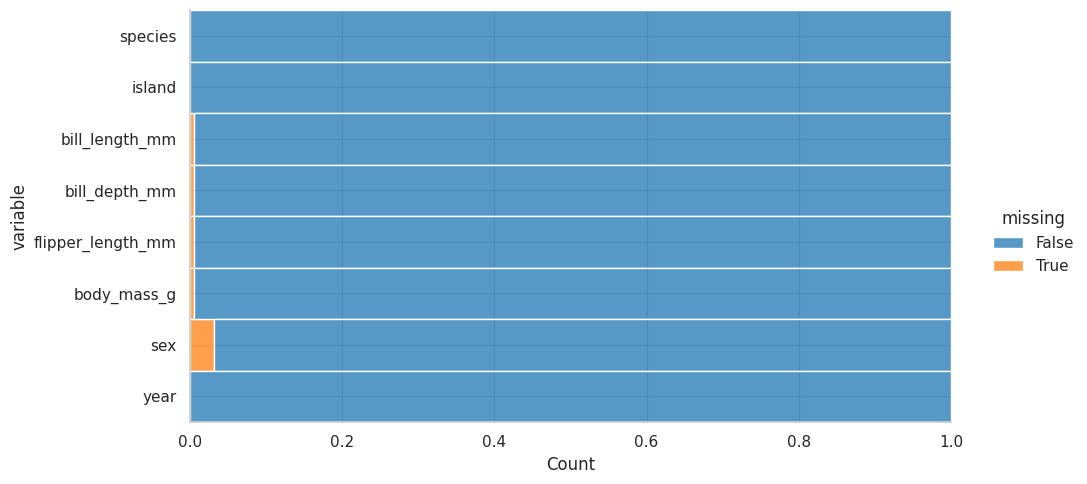

In [38]:
# ¿Cuál es la proporción de valores nulos por cada variable?
df.isnull().melt(value_name='missing').pipe(
        lambda x: sns.displot(
            data=x,
            y='variable',
            hue='missing',
            multiple='fill',
            aspect=2)
    )

<Axes: >

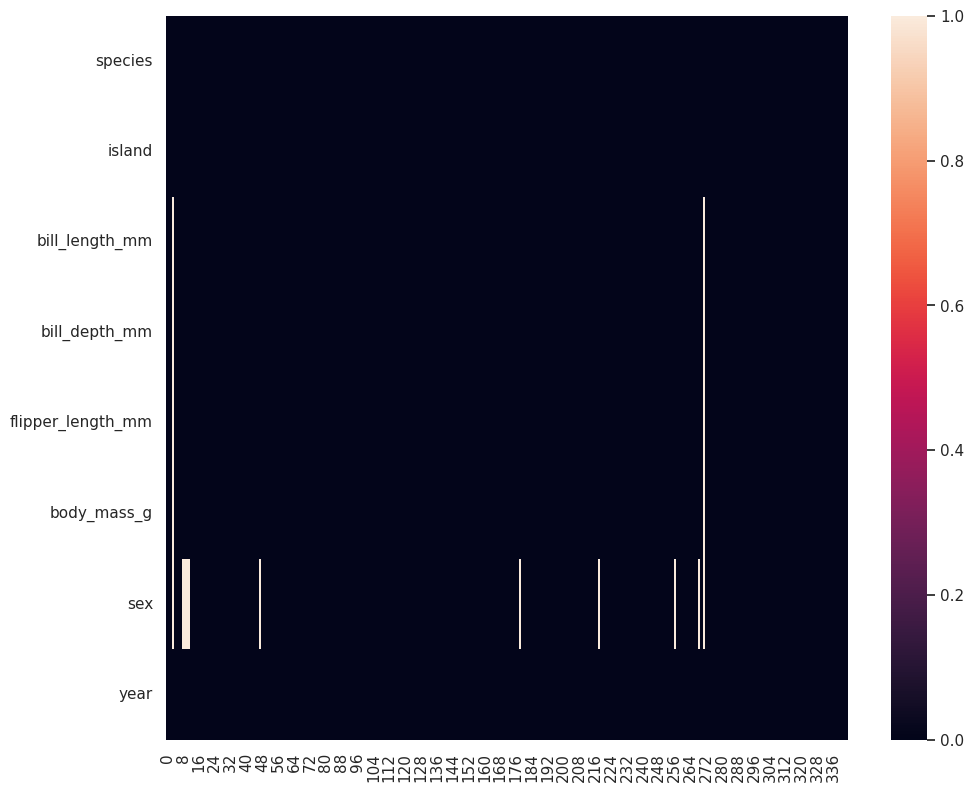

In [37]:
# ¿Cómo podemos visualizar los valores nulos en todo el conjunto de datos?
df.isnull().transpose().pipe(lambda df: sns.heatmap(data=df))

In [40]:
# ¿Cuántas observaciones perdemos si eliminamos los datos faltantes?
processed_df = df.dropna()
processed_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


## Conteos y proporciones

In [42]:
# ¿Qué estadísticos describen el conjunto de datos?
processed_df.describe(include='all').round(2)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
count,333,333,333.00,333.00,333.00,333.00,333,333.00
unique,3,3,NaN,NaN,NaN,NaN,2,NaN
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,male,NaN
freq,146,163,NaN,NaN,NaN,NaN,168,NaN
mean,NaN,NaN,43.99,17.16,200.97,4207.06,NaN,2008.04
std,NaN,NaN,5.47,1.97,14.02,805.22,NaN,0.81
min,NaN,NaN,32.10,13.10,172.00,2700.00,NaN,2007.00
25%,NaN,NaN,39.50,15.60,190.00,3550.00,NaN,2007.00
50%,NaN,NaN,44.50,17.30,197.00,4050.00,NaN,2008.00
75%,NaN,NaN,48.60,18.70,213.00,4775.00,NaN,2009.00


In [44]:
# Solo las numéricas
processed_df.describe(include=[np.number]).round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.00,333.00,333.00,333.00,333.00
mean,43.99,17.16,200.97,4207.06,2008.04
std,5.47,1.97,14.02,805.22,0.81
min,32.10,13.10,172.00,2700.00,2007.00
25%,39.50,15.60,190.00,3550.00,2007.00
50%,44.50,17.30,197.00,4050.00,2008.00
75%,48.60,18.70,213.00,4775.00,2009.00
max,59.60,21.50,231.00,6300.00,2009.00


In [45]:
# Solo categóricas - 1
processed_df.describe(include=object)

,species,island,sex
count,333,333,333
unique,3,3,2
top,Adelie,Biscoe,male
freq,146,163,168


In [47]:
# Solo categóricas - 2
(
    processed_df
    .astype(
        {
            'species': 'category',
            'island': 'category',
            'sex': 'category'
        }
    )
    .describe(include=['category', object])
)

,species,island,sex
count,333,333,333
unique,3,3,2
top,Adelie,Biscoe,male
freq,146,163,168


### ¿Cómo visualizar los conteos?

<Axes: xlabel='species'>

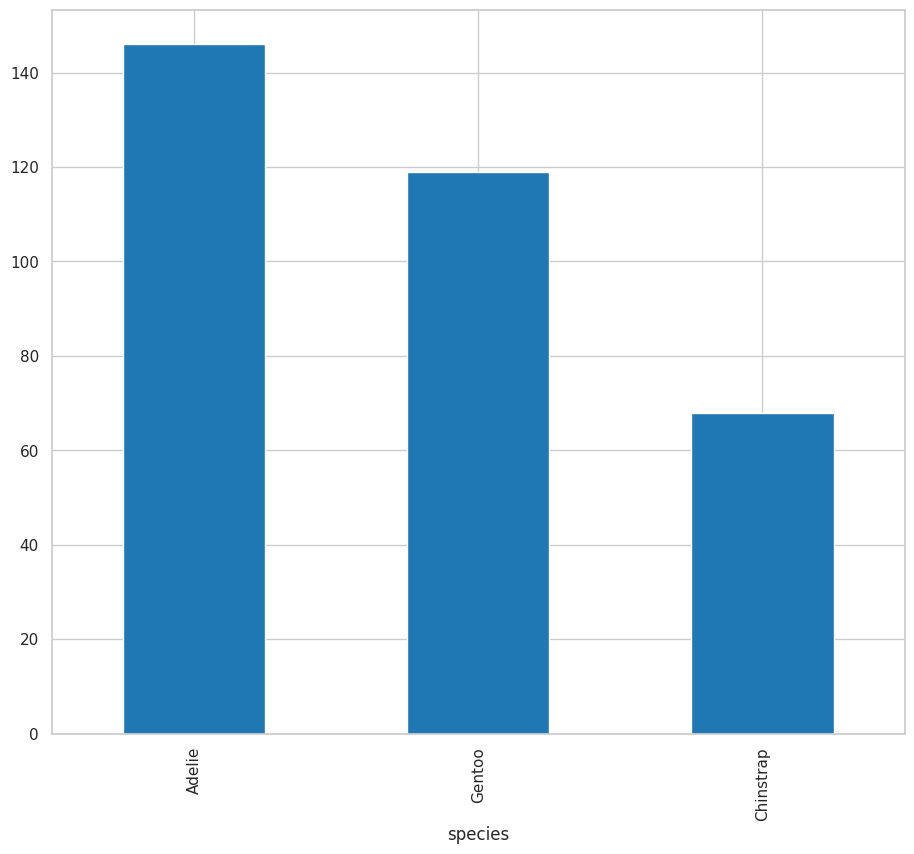

In [49]:
# Pandas
processed_df.species.value_counts().plot(
        kind='bar',
        # color=penguin_color.values()
    )

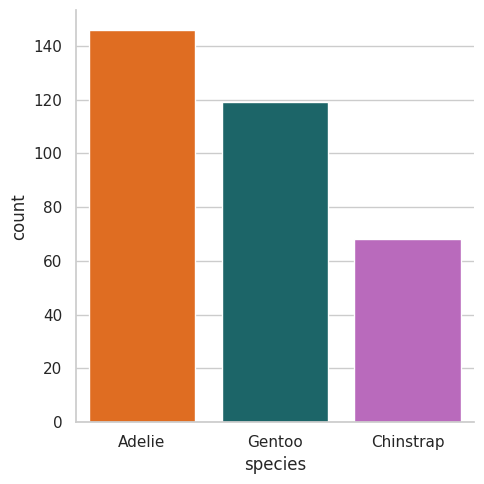

In [56]:
# Seaborn
sns.catplot(
    data=processed_df,
    x='species',
    kind='count',
    hue='species',
    palette=penguin_color,
    legend=False
    # order=processed_df.value_counts('species', sort=True).index
)

<Axes: xlabel='species', ylabel='count'>

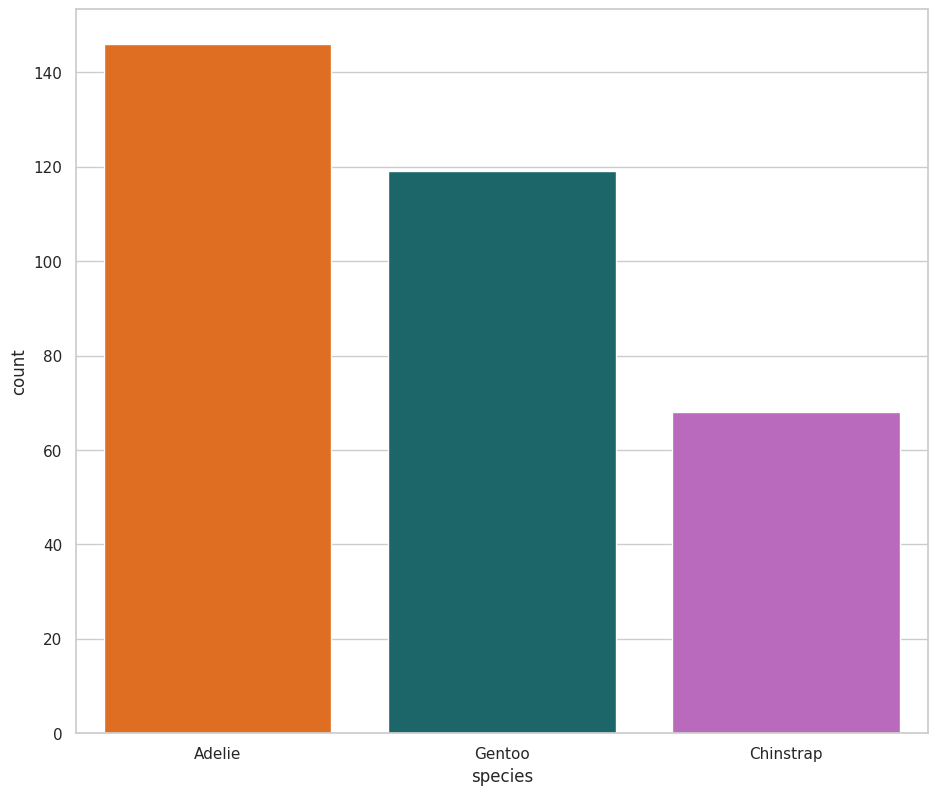

In [53]:
(
    processed_df
    .value_counts('species', sort=True)
    .reset_index(name='count')
    .pipe(
        lambda df: (
            sns.barplot(
                data=df,
                x='species',
                y='count',
                hue='species',     # Asigna la variable al color
                palette=penguin_color,
                legend=False       # Oculta la leyenda
            )
        )
    )
)

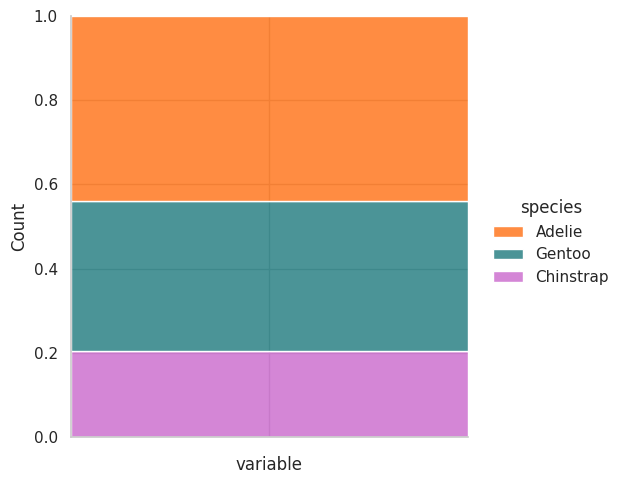

In [59]:
# ¿Cómo visualizar las proporciones?
(
    processed_df
    .add_column('variable', '')
    .pipe(
        lambda df: (
            sns.displot(
                data=df,
                x='variable',
                hue='species',
                multiple='fill',
                palette=penguin_color
            )
        )
    )
)

### Extendiendo la idea de conteo

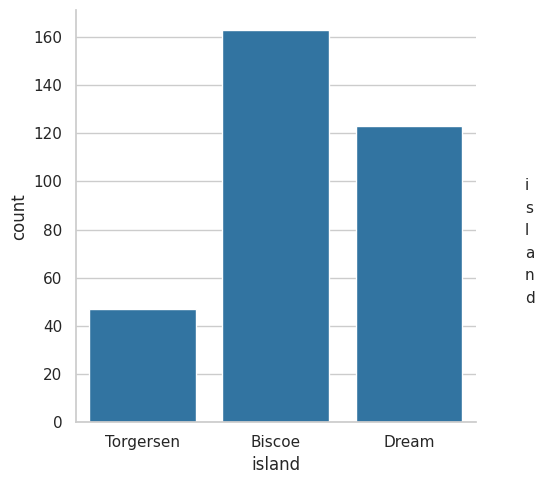

In [61]:
# Por islas
sns.catplot(
    data=processed_df,
    x='island',
    kind='count',
    hue_order='island',
)

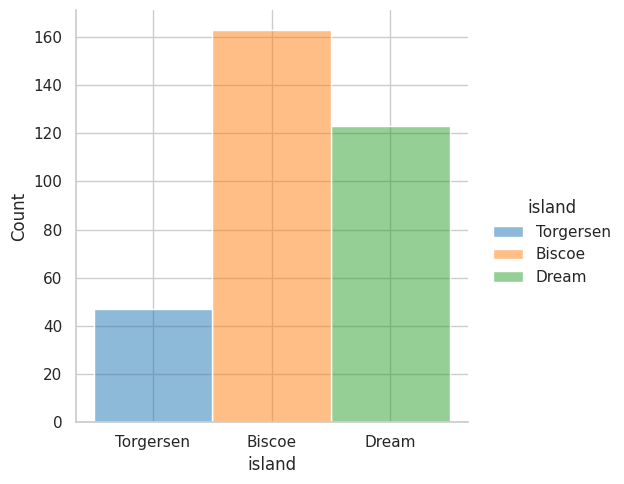

In [62]:
sns.displot(
    data=processed_df,
    x='island',
    hue='island',
)

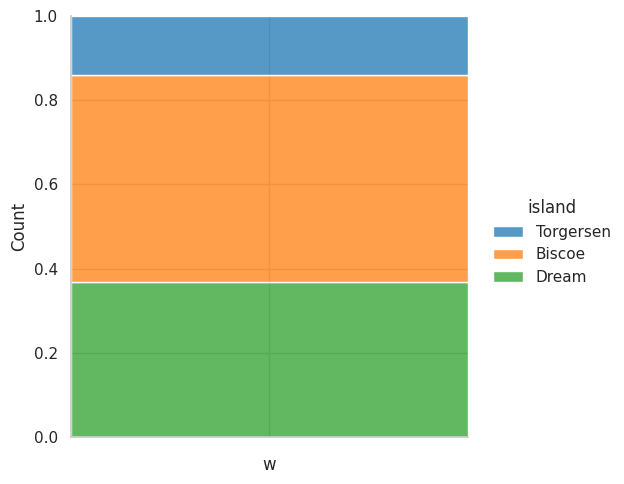

In [63]:
(
    processed_df
    .assign(w='') #Añade una columna vacía
    .pipe(
        lambda df: (
            sns.displot(
                data=df,
                x='w',
                hue='island',
                multiple='fill',
            )

        )
    )
)

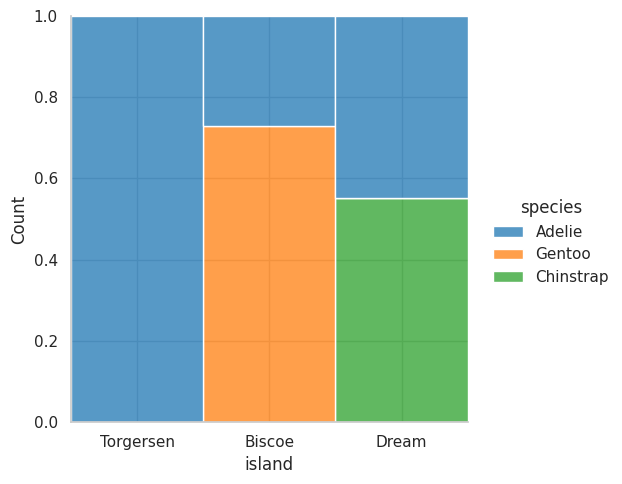

In [66]:
sns.displot(
    data=processed_df,
    x='island',
    hue='species',
    multiple = 'fill'
)

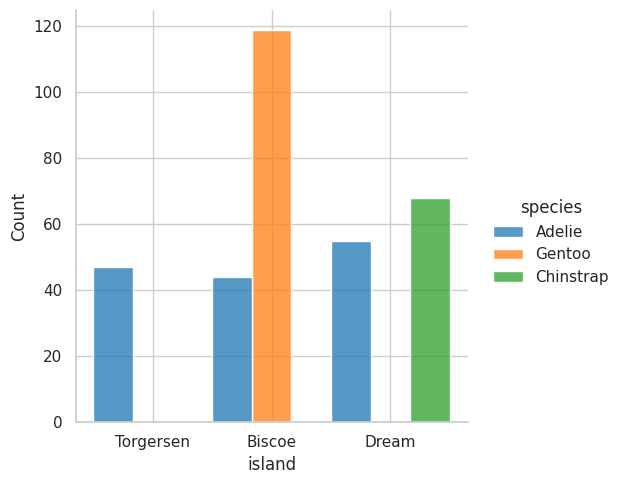

In [68]:
sns.displot(
    data=processed_df,
    x='island',
    hue='species',
    multiple = 'dodge'
)

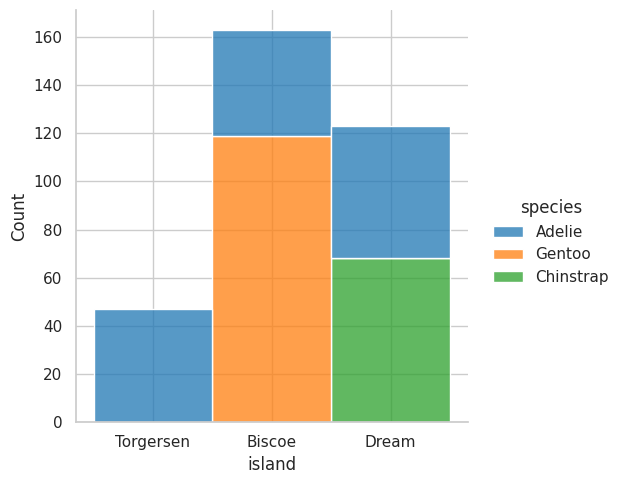

In [71]:
sns.displot(
    data=processed_df,
    x='island',
    hue='species',
    multiple = 'stack'
)

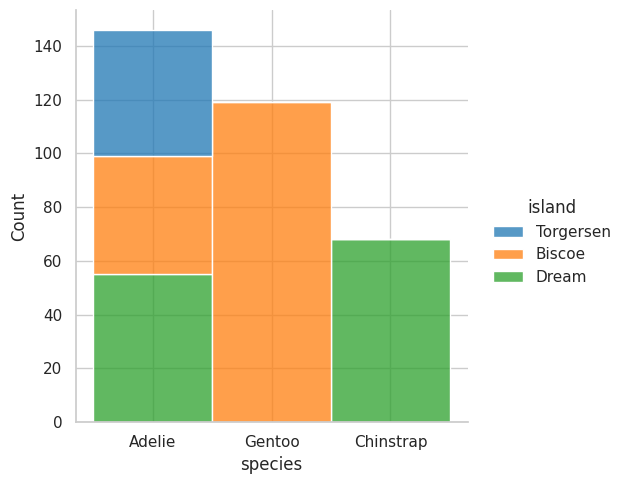

In [72]:
sns.displot(
    data=processed_df,
    x='species',
    hue='island',
    multiple = 'stack'
)

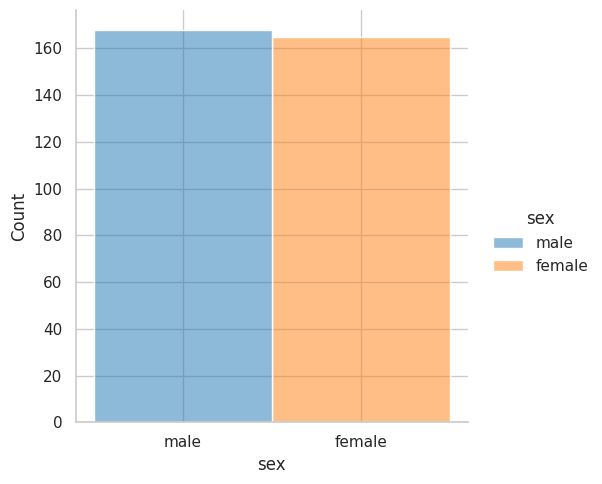

In [64]:
sns.displot(
    data=processed_df,
    x='sex',
    hue='sex',
)

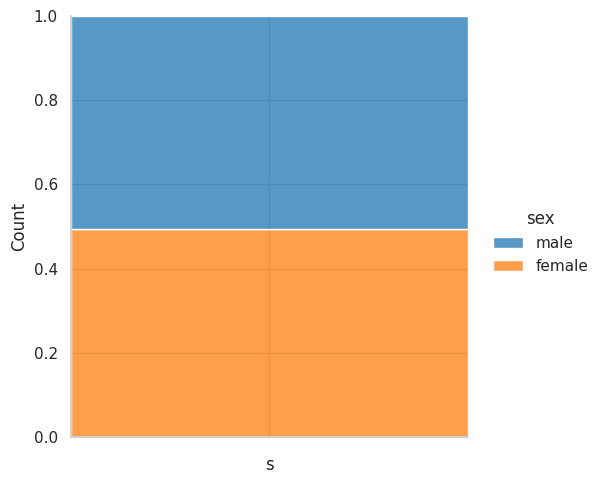

In [65]:
(
    processed_df
    .assign(s='') #Añade una columna vacía
    .pipe(
        lambda df: (
            sns.displot(
                data=df,
                x='s',
                hue='sex',
                multiple='fill',
            )

        )
    )
)